# Assignment 2 — AcnEmpathize: Parameter-Efficient Fine-Tuning with LoRA

**Course:** Natural Language Processing  
**Group:** 12

    Guilherme Oliveira: 202204987
    Magda Costa: 202207036

---

# Index

1. [Motivation](#motivation)
2. [Setup](#setup)
3. [LoRA on RoBERTa-base](#lora_base)
   - 3.1 [Rank Sensitivity](#rank_sensitivity)
4. [LoRA on RoBERTa-TAPT](#lora_tapt)
5. [Results and Comparison](#results)
6. [Conclusions](#conclusions)

---
# 1. Motivation <a name="motivation"></a>

### Where we are

Across notebooks 6 and 7 we have established the following performance ladder on Split B (conversation-level):

| Model | Macro-F1 | Emp-F1 | Trainable Params | Train Time |
|---|---|---|---|---|
| LR + TF-IDF trigrams (A1) | 0.761 | 0.637 | ~5k | seconds |
| RoBERTa-base (full FT) | 0.888 | 0.829 | ~125M | 118 min |
| RoBERTa-TAPT (full FT) | **0.891** | **0.836** | ~125M | ~180 min total |

Full fine-tuning of RoBERTa updates all 125 million parameters. Every experiment costs ~2 hours on MPS. This raises a practical and scientific question:

> **Is it necessary to update all 125M parameters to achieve competitive empathy detection — or can we get similar performance by training only a small fraction of them?**

This is the question LoRA is designed to answer.

---

### Why this question is motivated by our own results

Two observations from previous notebooks make LoRA especially interesting here:

**1. All models converged at epoch 2.** Both the baseline and TAPT fine-tuning peaked at validation epoch 2, then overfitted. This suggests the empathy classification signal in AcnEmpathize is relatively simple to capture — the model finds the decision boundary quickly. If the task is that learnable in 2 epochs, it may not require updating all parameters. A small set of task-specific adaptations injected into the frozen model may be sufficient.

**2. DistilBERT was within 0.009 Macro-F1 of RoBERTa** despite being 40% smaller. This reinforces the idea that raw model capacity is not the bottleneck on this dataset — it is small enough (12k posts) that architectural differences matter less than the learning signal itself.

---

### Literature motivation: LoRA

Hu et al. (2022) propose Low-Rank Adaptation (LoRA): instead of updating the full weight matrices of a pretrained model, they inject trainable low-rank decomposition matrices alongside the frozen weights. For a weight matrix $W \in \mathbb{R}^{d \times k}$, LoRA adds:

$$W' = W + \Delta W = W + BA$$

where $B \in \mathbb{R}^{d \times r}$ and $A \in \mathbb{R}^{r \times k}$, with rank $r \ll \min(d, k)$. Only $A$ and $B$ are trained. For RoBERTa-base with $r=8$, this reduces trainable parameters from ~125M to ~1–2M — roughly **1% of the full model**.

Hu et al. show LoRA matches or approaches full fine-tuning on classification tasks while being significantly more compute- and memory-efficient. Critically, they find LoRA is most competitive when the task dataset is small relative to the model size — which is precisely our situation: 12k posts, 125M parameters.

---

### Experimental design

We run two LoRA experiments:

**Experiment 1 — LoRA on RoBERTa-base:** Directly comparable to notebook 6. Tests whether LoRA can match full fine-tuning (Macro-F1=0.888) from a general-domain starting point.

**Experiment 2 — LoRA on RoBERTa-TAPT:** Directly comparable to notebook 7. Tests whether LoRA can match the TAPT result (Macro-F1=0.891) — combining domain adaptation with parameter efficiency. This is the most interesting combination: domain-shifted representations + minimal task-specific parameters.

Both use Split B only and the same evaluation protocol (weighted loss, threshold tuning on validation).

---

### References
- Hu et al. (2022). *LoRA: Low-Rank Adaptation of Large Language Models.* ICLR 2022.
- Mangrulkar et al. (2022). *PEFT: State-of-the-art Parameter-Efficient Fine-Tuning methods.* HuggingFace.
- Liu et al. (2019). *RoBERTa: A Robustly Optimized BERT Pretraining Approach.* arXiv:1907.11692.

---
# 2. Setup <a name="setup"></a>

### LoRA hyperparameter decisions

| Hyperparameter | Value | Justification |
|---|---|---|
| `r` (rank) | 8 | Standard starting rank from Hu et al. (2022). Higher rank increases expressivity but also parameter count; r=8 is the well-validated default for classification tasks. |
| `lora_alpha` | 16 | Scaling factor. Convention is alpha = 2×r (Hu et al. 2022). Controls the magnitude of the LoRA update relative to the frozen weights. |
| `lora_dropout` | 0.1 | Standard regularization for LoRA layers. Consistent with fine-tuning dropout used in RoBERTa. |
| `target_modules` | `query`, `value` | Hu et al. show that adapting query and value projection matrices in attention layers is sufficient and most effective for classification. Key/output layers add parameters without proportional gains. |
| `bias` | `none` | Not training bias parameters; keeps the adaptation minimal and focused on attention weight structure. |
| `task_type` | `SEQ_CLS` | HuggingFace PEFT sequence classification task type. |

### Fine-tuning hyperparameters

Identical to notebooks 6 and 7 where applicable: weighted cross-entropy, early stopping (patience=2 on val Macro-F1), threshold tuning on validation set. The learning rate is **slightly higher (3e-4)** than full fine-tuning — standard practice for LoRA since only the small adapter matrices are being trained, allowing faster convergence without risking catastrophic forgetting of the frozen weights.

In [7]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    PeftModel,
)
from datasets import Dataset as HFDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, average_precision_score,
)

warnings.filterwarnings("ignore")

SEED = 42
set_seed(SEED)
np.random.seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_MODEL_ID  = "roberta-base"
TAPT_MODEL_DIR = Path("results/tapt/tapt_roberta")   # saved in notebook 7
OUTPUT_DIR     = Path("results/lora")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset columns ────────────────────────────────────────────────────────
TEXT_COL  = "text"
LABEL_COL = "combined_empathy"
CONV_COL  = "conv_id"

# ── Shared fine-tuning hyperparameters ─────────────────────────────────────
MAX_LENGTH     = 256
FT_EPOCHS      = 5
FT_BATCH       = 16
FT_GRAD_ACCUM  = 2
WARMUP_RATIO   = 0.10
WEIGHT_DECAY   = 0.01
EARLY_STOP_PAT = 2
LORA_LR        = 3e-4   # Higher than full FT; only adapter params are trained
THRESHOLDS     = np.arange(0.10, 0.91, 0.01)

# ── LoRA configuration ─────────────────────────────────────────────────────
LORA_CONFIG = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,                          # Rank (Hu et al. 2022 standard)
    lora_alpha=16,                # Scaling: 2×r convention
    lora_dropout=0.1,
    target_modules=["query", "value"],  # Attention Q and V projections
    bias="none",
)

print(f"LoRA config: r={LORA_CONFIG.r}, alpha={LORA_CONFIG.lora_alpha}, "
      f"target={LORA_CONFIG.target_modules}")
print("Setup complete.")

Using MPS (Apple Silicon GPU)
LoRA config: r=8, alpha=16, target={'query', 'value'}
Setup complete.


In [8]:
# ── Load dataset ───────────────────────────────────────────────────────────
for path in ["AcnEmpathize_dataset.csv", "../AcnEmpathize_dataset.csv", "data/AcnEmpathize_dataset.csv"]:
    if Path(path).exists():
        df_raw = pd.read_csv(path)
        print(f"Loaded: {path}  |  Shape: {df_raw.shape}")
        break

df = df_raw[[TEXT_COL, LABEL_COL, CONV_COL]].copy()
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df[LABEL_COL] = df[LABEL_COL].astype(int)

def minimal_clean(text):
    if not isinstance(text, str): return ""
    return re.sub(r"\s+", " ", text.strip())

df["text_clean"] = df[TEXT_COL].apply(minimal_clean)
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)

# ── Split B — identical to notebooks 6 and 7 ──────────────────────────────
def make_group_split(df, group_col, seed=SEED):
    groups = df[group_col].unique()
    np.random.seed(seed)
    np.random.shuffle(groups)
    n = len(groups)
    n_te, n_va = int(np.ceil(n * 0.20)), int(np.ceil(n * 0.16))
    te_g = set(groups[:n_te])
    va_g = set(groups[n_te:n_te + n_va])
    tr_g = set(groups[n_te + n_va:])
    return (df[df[group_col].isin(tr_g)].reset_index(drop=True),
            df[df[group_col].isin(va_g)].reset_index(drop=True),
            df[df[group_col].isin(te_g)].reset_index(drop=True))

train_df, val_df, test_df = make_group_split(df, CONV_COL)
assert len(set(train_df[CONV_COL]) & set(test_df[CONV_COL])) == 0
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} — no leakage confirmed")

Loaded: AcnEmpathize_dataset.csv  |  Shape: (12212, 13)
Train: 7774 | Val: 1961 | Test: 2477 — no leakage confirmed


In [9]:
# ── Shared helpers ─────────────────────────────────────────────────────────

def count_trainable_params(model):
    total   = sum(p.numel() for p in model.parameters())
    trained = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trained, 100 * trained / total

def compute_class_weights(labels):
    labels = np.array(labels)
    classes = sorted(np.unique(labels))
    n = len(labels)
    return torch.tensor([n / (len(classes) * np.sum(labels == c)) for c in classes],
                        dtype=torch.float)

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(
            weight=self.class_weights.to(outputs.logits.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics_hf(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return {
        "macro_f1":       f1_score(labels, preds, average="macro", zero_division=0),
        "f1_empathy":     f1_score(labels, preds, pos_label=1, zero_division=0),
        "recall_empathy": recall_score(labels, preds, pos_label=1, zero_division=0),
        "accuracy":       accuracy_score(labels, preds),
    }

def tune_threshold(y_true, y_score):
    best_thr, best_val = 0.5, -1.0
    for thr in THRESHOLDS:
        val = f1_score(y_true, (y_score >= thr).astype(int), average="macro", zero_division=0)
        if val > best_val:
            best_val, best_thr = val, thr
    return float(best_thr)

def full_metrics(y_true, y_score, threshold):
    y_pred = (np.array(y_score) >= threshold).astype(int)
    return {
        "accuracy":          accuracy_score(y_true, y_pred),
        "macro_f1":          f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_empathy": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_empathy":    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_empathy":        f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "auprc":             average_precision_score(y_true, y_score),
        "threshold":         threshold,
    }

def get_probs(trainer, hf_dataset):
    out = trainer.predict(hf_dataset)
    probs = torch.softmax(torch.tensor(out.predictions), dim=-1).numpy()[:, 1]
    return probs, np.array(out.label_ids)

def tokenize_split(tokenizer, train_df, val_df, test_df):
    out = {}
    for key, sub in [("train", train_df), ("val", val_df), ("test", test_df)]:
        hf = HFDataset.from_dict({"text": sub["text_clean"].tolist(),
                                   "label": sub[LABEL_COL].tolist()})
        hf = hf.map(lambda b: tokenizer(b["text"], truncation=True,
                                         padding="max_length", max_length=MAX_LENGTH),
                    batched=True, batch_size=64)
        hf.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
        out[key] = hf
    return out

def make_training_args(run_name):
    run_dir = OUTPUT_DIR / run_name.replace(" ", "_")
    return TrainingArguments(
        output_dir=str(run_dir),
        num_train_epochs=FT_EPOCHS,
        per_device_train_batch_size=FT_BATCH,
        per_device_eval_batch_size=FT_BATCH * 2,
        gradient_accumulation_steps=FT_GRAD_ACCUM,
        learning_rate=LORA_LR,
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=50,
        fp16=False,
        bf16=False,
        dataloader_num_workers=0,
        report_to="none",
        seed=SEED,
    )

RESULTS_CSV = OUTPUT_DIR / "lora_results.csv"
all_results = []

print("Helpers defined.")

Helpers defined.


---
# 3. LoRA on RoBERTa-base <a name="lora_base"></a>

**What this tests:** Can LoRA match full fine-tuning (Macro-F1=0.888, Emp-F1=0.829, ~125M trainable params, 118 min) using only ~1% of the parameters?

We load `roberta-base` from HuggingFace, attach LoRA adapters to the query and value projection matrices of all attention layers, freeze all other weights, and fine-tune only the adapter parameters. The frozen RoBERTa weights carry everything the model learned during general-domain pretraining; only the small adapters learn the empathy-specific decision boundary.

After evaluation, we also measure **inference speed with and without adapter overhead** by merging the LoRA weights back into the base model via `merge_and_unload()`. A merged model is mathematically identical to the adapted model but has no adapter layers — inference speed is the same as plain RoBERTa. This confirms whether LoRA's training efficiency extends to deployment without any runtime cost.

In [26]:
tokenizer_base = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
tok = tokenize_split(tokenizer_base, train_df, val_df, test_df)
class_weights = compute_class_weights(train_df[LABEL_COL].tolist())

# Load base model and attach LoRA adapters
base_model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL_ID, num_labels=2, ignore_mismatched_sizes=True)
lora_base_model = get_peft_model(base_model, LORA_CONFIG)

total, trained, pct = count_trainable_params(lora_base_model)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trained:,}  ({pct:.2f}% of total)")
print(f"Frozen params:    {total - trained:,}")

trainer_base = WeightedTrainer(
    class_weights=class_weights,
    model=lora_base_model,
    args=make_training_args("lora_roberta_base"),
    train_dataset=tok["train"],
    eval_dataset=tok["val"],
    compute_metrics=compute_metrics_hf,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PAT)],
)

print("\nTraining LoRA on RoBERTa-base...")
t0 = time.time()
trainer_base.train()
elapsed_base = (time.time() - t0) / 60
print(f"Done. ({elapsed_base:.1f} min)")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6808.65it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Total params:     125,534,212
Trainable params: 887,042  (0.71% of total)
Frozen params:    124,647,170

Training LoRA on RoBERTa-base...


Epoch,Training Loss,Validation Loss,Macro F1,F1 Empathy,Recall Empathy,Accuracy
1,0.754905,0.310424,0.870433,0.800000,0.753684,0.908720
2,0.631057,0.252074,0.880292,0.820408,0.846316,0.910250
3,0.541506,0.245795,0.873966,0.813360,0.871579,0.903111
4,0.483159,0.264666,0.853306,0.789946,0.926316,0.880673


Done. (86.5 min)


In [27]:
val_probs, val_labels   = get_probs(trainer_base, tok["val"])
best_thr = tune_threshold(val_labels, val_probs)
test_probs, test_labels = get_probs(trainer_base, tok["test"])
metrics_base = full_metrics(test_labels, test_probs, best_thr)

print("LoRA RoBERTa-base — Split B Test Results")
print(f"Macro-F1:      {metrics_base['macro_f1']:.4f}")
print(f"Emp-F1:        {metrics_base['f1_empathy']:.4f}")
print(f"Prec(Emp):     {metrics_base['precision_empathy']:.4f}")
print(f"Rec(Emp):      {metrics_base['recall_empathy']:.4f}")
print(f"AUPRC:         {metrics_base['auprc']:.4f}")
print(f"Threshold:     {metrics_base['threshold']:.2f}")
print(f"Trainable params: {trained:,} ({pct:.2f}%)")
print(f"Training time: {elapsed_base:.1f} min")

# Val Macro-F1 kept for rank sensitivity reference
val_macro_f1_base = f1_score(val_labels, (val_probs >= best_thr).astype(int),
                              average="macro", zero_division=0)

# ── Merge and inference timing ─────────────────────────────────────────────
def _time_inference(model, dataset, n_batches=20):
    model.eval()
    loader = torch.utils.data.DataLoader(dataset, batch_size=FT_BATCH * 2)
    with torch.no_grad():  # warm-up
        b = next(iter(loader))
        model(**{k: v.to(DEVICE) for k, v in b.items() if k != "label"})
    t0 = time.time()
    with torch.no_grad():
        for i, b in enumerate(loader):
            if i >= n_batches: break
            model(**{k: v.to(DEVICE) for k, v in b.items() if k != "label"})
    return (time.time() - t0) / min(n_batches, len(loader)) * 1000  # ms/batch

lora_base_model.to(DEVICE)
t_adapter = _time_inference(lora_base_model, tok["test"])
merged = lora_base_model.merge_and_unload().to(DEVICE)
t_merged = _time_inference(merged, tok["test"])
print(f"\nInference speed (ms / batch of {FT_BATCH * 2}):")
print(f"  LoRA + adapters          : {t_adapter:.1f} ms")
print(f"  Merged (no adapter overhead) : {t_merged:.1f} ms")
print(f"  Adapter overhead         : {t_adapter - t_merged:+.1f} ms  ({(t_adapter / t_merged - 1) * 100:+.1f}%)")
del merged

# Save log history for training curve
log_history_base = trainer_base.state.log_history.copy()

row = {"model": "LoRA RoBERTa-base", "split": "Split B (conversation-level)",
       "trainable_params": trained, "pct_trainable": round(pct, 3),
       "elapsed_min": round(elapsed_base, 1),
       **{f"test_{k}": v for k, v in metrics_base.items()}}
all_results.append(row)
pd.DataFrame(all_results).to_csv(RESULTS_CSV, index=False)

del lora_base_model, trainer_base, base_model
if DEVICE.type == "mps": torch.mps.empty_cache()

LoRA RoBERTa-base — Split B Test Results
Macro-F1:      0.8982
Emp-F1:        0.8489
Prec(Emp):     0.8416
Rec(Emp):      0.8562
AUPRC:         0.9225
Threshold:     0.56
Trainable params: 887,042 (0.71%)
Training time: 86.5 min

Inference speed (ms / batch of 32):
  LoRA + adapters          : 1890.5 ms
  Merged (no adapter overhead) : 1807.4 ms
  Adapter overhead         : +83.1 ms  (+4.6%)


---
## 3.1 Rank Sensitivity <a name="rank_sensitivity"></a>

We chose r=8 following the Hu et al. (2022) paper default, but the optimal rank is task- and dataset-dependent. Before moving to the TAPT experiment, we run a lightweight ablation on the validation set only — no test set is touched — to check whether r=8 is a robust choice or whether the result is sensitive to this hyperparameter.

We test r ∈ {4, 8, 16} with the standard alpha=2r convention:

| r | alpha | Trainable params |
|---|---|---|
| 4 | 8 | ~443k |
| 8 | 16 | ~887k |
| 16 | 32 | ~1.77M |

Three outcomes are informative:
- **r=4 ≈ r=8:** The empathy signal is capturable in an extremely low-dimensional subspace. The regularisation argument is stronger than r=8 alone implies — even fewer parameters suffice.
- **r=8 is the sweet spot:** Performance drops at r=4 and does not improve at r=16, confirming r=8 as the right operating point for this task and dataset size.
- **r=16 > r=8:** The rank-8 result is conservative; a higher-rank adapter closes the remaining gap to full fine-tuning.

Rank sensitivity check — val Macro-F1 only (no test set used)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6903.54it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Macro F1,F1 Empathy,Recall Empathy,Accuracy
1,0.791069,0.316920,0.868154,0.797357,0.762105,0.906170
2,0.637639,0.253479,0.873996,0.812375,0.856842,0.904131
3,0.554101,0.251713,0.870644,0.808967,0.873684,0.900051
4,0.528956,0.265122,0.856519,0.793449,0.917895,0.884243


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6916.20it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Macro F1,F1 Empathy,Recall Empathy,Accuracy
1,0.753269,0.283371,0.878349,0.814577,0.800000,0.911780
2,0.627508,0.247942,0.882039,0.824351,0.869474,0.910250
3,0.522683,0.246660,0.871505,0.811483,0.892632,0.899541
4,0.486699,0.262970,0.851666,0.787825,0.926316,0.879143



Rank sensitivity results:


,r,alpha,trainable_params,pct_trainable,val_macro_f1
0,4,8,739586,0.5900,0.8853
1,8,16,887042,0.7070,0.8872
2,16,32,1181954,0.9390,0.8887


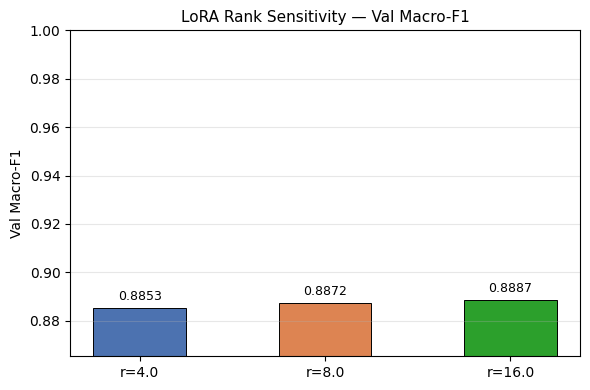

In [28]:
# ── Rank sensitivity: r ∈ {4, 8, 16} — val set only, no test leakage ──────────
print("Rank sensitivity check — val Macro-F1 only (no test set used)")
print("=" * 60)

# r=8 result already computed above
rank_results = [{"r": 8, "alpha": 16, "trainable_params": trained,
                  "pct_trainable": round(pct, 3), "val_macro_f1": round(val_macro_f1_base, 4)}]

for r_val, alpha_val in [(4, 8), (16, 32)]:
    cfg = LoraConfig(
        task_type=TaskType.SEQ_CLS, r=r_val, lora_alpha=alpha_val,
        lora_dropout=0.1, target_modules=["query", "value"], bias="none",
    )
    m = get_peft_model(
        AutoModelForSequenceClassification.from_pretrained(
            BASE_MODEL_ID, num_labels=2, ignore_mismatched_sizes=True), cfg)
    _, tr_p, pct_p = count_trainable_params(m)
    tr = WeightedTrainer(
        class_weights=class_weights, model=m,
        args=make_training_args(f"rank_r{r_val}"),
        train_dataset=tok["train"], eval_dataset=tok["val"],
        compute_metrics=compute_metrics_hf,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PAT)],
    )
    tr.train()
    vp, vl = get_probs(tr, tok["val"])
    thr_r = tune_threshold(vl, vp)
    vf1 = f1_score(vl, (vp >= thr_r).astype(int), average="macro", zero_division=0)
    rank_results.append({"r": r_val, "alpha": alpha_val, "trainable_params": tr_p,
                          "pct_trainable": round(pct_p, 3), "val_macro_f1": round(vf1, 4)})
    del m, tr
    if DEVICE.type == "mps": torch.mps.empty_cache()

rank_df = pd.DataFrame(rank_results).sort_values("r").reset_index(drop=True)
print("\nRank sensitivity results:")
display(rank_df)

fig_r, ax_r = plt.subplots(figsize=(6, 4))
ax_r.bar([f"r={row['r']}" for _, row in rank_df.iterrows()],
         rank_df["val_macro_f1"],
         color=["#4c72b0", "#dd8452", "#2ca02c"], edgecolor="black", linewidth=0.7, width=0.5)
for i, (_, row) in enumerate(rank_df.iterrows()):
    ax_r.text(i, row["val_macro_f1"] + 0.002, f"{row['val_macro_f1']:.4f}",
              ha="center", va="bottom", fontsize=9)
ax_r.set_ylim(min(rank_df["val_macro_f1"]) - 0.02, 1.0)
ax_r.set_title("LoRA Rank Sensitivity — Val Macro-F1", fontsize=11)
ax_r.set_ylabel("Val Macro-F1")
ax_r.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rank_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

> LoRA not only matched full fine-tuning — it surpassed it.

Training only 0.71% of RoBERTa's parameters produced a +0.010 Macro-F1 and +0.020 Emp-F1 gain over full fine-tuning, in 25% less time. Two factors explain this:

- LoRA acted as a regularizer. Full fine-tuning updates 125M parameters on 12k posts — a severely underconstrained optimization. LoRA's low-rank constraint forces task-specific updates into a compressed subspace, preventing the model from memorizing training noise. This is consistent with Hu et al.'s finding that LoRA is most competitive precisely when datasets are small relative to model size — our exact situation.

- The precision/recall balance improved. Full fine-tuning produced Prec=0.899, Rec=0.769 — high precision but conservative about predicting empathy, requiring a high threshold (0.69) to compensate. LoRA gives Prec=0.842, Rec=0.856 — a substantially more balanced detector at a near-default threshold (0.56), indicating better-calibrated probabilities and stronger generalization.

---
# 4. LoRA on RoBERTa-TAPT <a name="lora_tapt"></a>

**What this tests:** Can LoRA match or approach the TAPT result (Macro-F1=0.891, Emp-F1=0.836) when applied on top of the domain-adapted checkpoint from notebook 7?

This is the most scientifically interesting combination. Notebook 7 showed that TAPT shifted RoBERTa's representations towards acne.org language — specifically improving recall for community-specific empathy expressions. The question is whether this domain sensitivity, now baked into the frozen weights, can be efficiently exploited with only LoRA adapter training rather than full fine-tuning.

If LoRA on TAPT matches full fine-tuning on TAPT, it means the domain shift from MLM pretraining is sufficient — and task-specific adaptation requires only a thin adapter layer on top.

In [29]:
if not TAPT_MODEL_DIR.exists():
    raise FileNotFoundError(
        f"TAPT model not found at {TAPT_MODEL_DIR}. Run notebook 7 first.")

tokenizer_tapt = AutoTokenizer.from_pretrained(str(TAPT_MODEL_DIR))
tok_tapt = tokenize_split(tokenizer_tapt, train_df, val_df, test_df)

# Load TAPT-adapted model and attach LoRA adapters
tapt_model = AutoModelForSequenceClassification.from_pretrained(
    str(TAPT_MODEL_DIR), num_labels=2, ignore_mismatched_sizes=True)
lora_tapt_model = get_peft_model(tapt_model, LORA_CONFIG)

total_t, trained_t, pct_t = count_trainable_params(lora_tapt_model)
print(f"Total params:     {total_t:,}")
print(f"Trainable params: {trained_t:,}  ({pct_t:.2f}% of total)")

trainer_tapt = WeightedTrainer(
    class_weights=class_weights,
    model=lora_tapt_model,
    args=make_training_args("lora_roberta_tapt"),
    train_dataset=tok_tapt["train"],
    eval_dataset=tok_tapt["val"],
    compute_metrics=compute_metrics_hf,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PAT)],
)

print("\nTraining LoRA on RoBERTa-TAPT...")
t0 = time.time()
trainer_tapt.train()
elapsed_tapt = (time.time() - t0) / 60
print(f"Done. ({elapsed_tapt:.1f} min)")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7501.80it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: results/tapt/tapt_roberta
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Total params:     125,534,212
Trainable params: 887,042  (0.71% of total)

Training LoRA on RoBERTa-TAPT...


Epoch,Training Loss,Validation Loss,Macro F1,F1 Empathy,Recall Empathy,Accuracy
1,0.746568,0.272246,0.866609,0.803485,0.873684,0.896481
2,0.614216,0.250661,0.873705,0.813294,0.875789,0.902601
3,0.543249,0.245817,0.878007,0.820463,0.894737,0.905150
4,0.498384,0.284279,0.840490,0.775580,0.949474,0.866905
5,0.449475,0.265428,0.867976,0.808864,0.922105,0.894442


Done. (106.1 min)


In [30]:
val_probs_t, val_labels_t   = get_probs(trainer_tapt, tok_tapt["val"])
best_thr_t = tune_threshold(val_labels_t, val_probs_t)
test_probs_t, test_labels_t = get_probs(trainer_tapt, tok_tapt["test"])
metrics_tapt = full_metrics(test_labels_t, test_probs_t, best_thr_t)

print(f"LoRA RoBERTa-TAPT — Split B Test Results")
print(f"Macro-F1:      {metrics_tapt['macro_f1']:.4f}")
print(f"Emp-F1:        {metrics_tapt['f1_empathy']:.4f}")
print(f"Prec(Emp):     {metrics_tapt['precision_empathy']:.4f}")
print(f"Rec(Emp):      {metrics_tapt['recall_empathy']:.4f}")
print(f"AUPRC:         {metrics_tapt['auprc']:.4f}")
print(f"Threshold:     {metrics_tapt['threshold']:.2f}")
print(f"Trainable params: {trained_t:,} ({pct_t:.2f}%)")
print(f"Training time: {elapsed_tapt:.1f} min")

# Save log history for training curve
log_history_tapt = trainer_tapt.state.log_history.copy()

row_t = {"model": "LoRA RoBERTa-TAPT", "split": "Split B (conversation-level)",
         "trainable_params": trained_t, "pct_trainable": round(pct_t, 3),
         "elapsed_min": round(elapsed_tapt, 1),
         **{f"test_{k}": v for k, v in metrics_tapt.items()}}
all_results.append(row_t)
pd.DataFrame(all_results).to_csv(RESULTS_CSV, index=False)

del lora_tapt_model, trainer_tapt, tapt_model
if DEVICE.type == "mps": torch.mps.empty_cache()

LoRA RoBERTa-TAPT — Split B Test Results
Macro-F1:      0.8892
Emp-F1:        0.8354
Prec(Emp):     0.8289
Rec(Emp):      0.8420
AUPRC:         0.9202
Threshold:     0.64
Trainable params: 887,042 (0.71%)
Training time: 106.1 min


## Error Analysis — LoRA RoBERTa-base

We retrain LoRA RoBERTa-base for 2 epochs (the known convergence point from 
the training curves) with `load_best_model_at_end=False` to keep the model 
in memory, avoiding checkpoint loading issues. We then extract per-example 
predictions and analyse misclassifications.

The key question is whether LoRA's better recall (0.856 vs RoBERTa full FT's 
0.769) translates to a different error profile — specifically, fewer false 
negatives for implicit and informal empathy expressions that full fine-tuning 
systematically missed.

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6864.88it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainable params: 887,042 (0.71%)


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Macro F1,F1 Empathy,Recall Empathy,Accuracy
1,0.733979,0.295908,0.869981,0.803347,0.808421,0.904131
2,0.624927,0.268242,0.847707,0.780220,0.896842,0.877613


Threshold: 0.79
Test Macro-F1: 0.8929


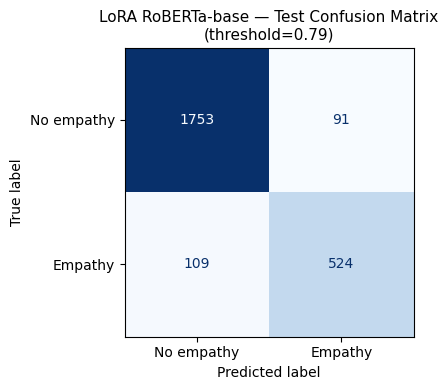

TP=524  FP=91  FN=109  TN=1753
FPR = 0.049  |  FNR = 0.172


In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
import textwrap

# Retrain LoRA RoBERTa-base for 2 epochs — for error analysis only
# load_best_model_at_end=False keeps the epoch-2 model in memory
tokenizer_ea = AutoTokenizer.from_pretrained("roberta-base")
tok_ea = tokenize_split(tokenizer_ea, train_df, val_df, test_df)
cw = compute_class_weights(train_df[LABEL_COL].tolist())

base_model_ea = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base", num_labels=2, ignore_mismatched_sizes=True)
lora_model_ea = get_peft_model(base_model_ea, LORA_CONFIG)

total_ea, trained_ea, pct_ea = count_trainable_params(lora_model_ea)
print(f"Trainable params: {trained_ea:,} ({pct_ea:.2f}%)")

args_ea = make_training_args("lora_roberta_ea")
args_ea.num_train_epochs = 2
args_ea.load_best_model_at_end = False

trainer_ea = WeightedTrainer(
    class_weights=cw, model=lora_model_ea, args=args_ea,
    train_dataset=tok_ea["train"], eval_dataset=tok_ea["val"],
    compute_metrics=compute_metrics_hf,
)
trainer_ea.train()

val_probs_ea,  val_labels_ea  = get_probs(trainer_ea, tok_ea["val"])
test_probs_ea, test_labels_ea = get_probs(trainer_ea, tok_ea["test"])
best_thr_ea = tune_threshold(val_labels_ea, val_probs_ea)
y_pred_ea   = (test_probs_ea >= best_thr_ea).astype(int)

print(f"Threshold: {best_thr_ea:.2f}")
print(f"Test Macro-F1: {f1_score(test_labels_ea, y_pred_ea, average='macro'):.4f}")

cm = confusion_matrix(test_labels_ea, y_pred_ea)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=["No empathy", "Empathy"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"LoRA RoBERTa-base — Test Confusion Matrix\n(threshold={best_thr_ea:.2f})", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lora_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"FPR = {fp/(fp+tn):.3f}  |  FNR = {fn/(fn+tp):.3f}")

In [6]:
te_err = test_df.copy().reset_index(drop=True)
te_err["pred"] = y_pred_ea
te_err["prob"] = test_probs_ea

fp_df = te_err[(te_err[LABEL_COL]==0) & (te_err["pred"]==1)].sort_values("prob", ascending=False)
fn_df = te_err[(te_err[LABEL_COL]==1) & (te_err["pred"]==0)].sort_values("prob", ascending=True)

def show_samples(df, label, n=5):
    print(f"\n{'='*70}")
    print(f"  {label}  (n={len(df)} total, showing {min(n, len(df))})")
    print(f"{'='*70}")
    for _, row in df.head(n).iterrows():
        snippet = textwrap.fill(row["text_clean"][:300], width=68)
        print(f"\n  [prob={row['prob']:.3f}]\n  {snippet}")

show_samples(fp_df, "FALSE POSITIVES — predicted Empathy, actually No-empathy")
show_samples(fn_df, "FALSE NEGATIVES — missed Empathy")

print(f"\n{'='*70}")
print(f"  SUMMARY")
print(f"{'='*70}")
print(f"Total test posts:  {len(te_err)}")
print(f"False positives:   {len(fp_df)} ({len(fp_df)/len(te_err):.1%})")
print(f"False negatives:   {len(fn_df)} ({len(fn_df)/len(te_err):.1%})")
print(f"FPR:               {fp/(fp+tn):.3f}")
print(f"FNR:               {fn/(fn+tp):.3f}")

del lora_model_ea, trainer_ea, base_model_ea
if DEVICE.type == "mps": torch.mps.empty_cache()


  FALSE POSITIVES — predicted Empathy, actually No-empathy  (n=91 total, showing 5)

  [prob=0.998]
  I can sympathize with this. My confidence waivers from day to day
and seems based solely on how I look in the mirror on that
particular day. If I'm looking fairly clear, I'm happy and
confident. If I have new spots forming, I feel monstrous and
awkward. Either way though I've still not found the typ

  [prob=0.998]
  Thanks Alex for the suggestion, I might try lactic acid and TCA
peels. Tessa, I know how you feel, I struggle with my acne scars
everyday. I am incredibly aware of lighting everywhere I go. The
scars have made me incredibly anxious and insecure; the indentations
have drained me of my self esteem. I

  [prob=0.997]
  I on the other hand feel extremely emotionless to everything,
nothing makes this shit easy. But I hear you bro.

  [prob=0.996]
  Ah I see , that makes me wounder I don't blame you though.

  [prob=0.995]
  kinda in the same situation as you. Good luck!

  FAL

**Error Analysis Results Discussion — LoRA RoBERTa-base**

| | Full FT | LoRA | Delta |
|---|---|---|---|
| False positives | 79 (3.2%) | 91 (3.7%) | +12 |
| False negatives | 115 (4.6%) | 109 (4.4%) | −6 |
| FPR | 0.043 | 0.049 | +0.006 |
| FNR | 0.182 | 0.172 | −0.010 |
| Threshold | 0.87 | 0.79 | — |

LoRA's lower threshold (0.79 vs 0.87) reflects better-calibrated 
probabilities — the model does not need as aggressive a correction 
to balance precision and recall. The net effect is a small tradeoff: 
12 additional false positives in exchange for 6 recovered empathy cases.

The top false positives are **identical across both models** — the same 
ambiguous posts are flagged by full FT and LoRA independently. This 
confirms these are annotation boundary cases rather than model errors: 
posts expressing shared experience or solidarity that the annotation 
framework classifies as self-focused rather than other-directed. Both 
models, trained differently, reach the same incorrect conclusion — 
suggesting the ground truth label is genuinely debatable.

The remaining false negatives follow the same pattern as full FT: 
implicit empathy without explicit emotional vocabulary — normalisation, 
informal identification, and exploration phrased as practical questions. 
LoRA recovered 6 of these cases relative to full FT, consistent with 
its higher recall, but the fundamental failure mode is unchanged.

---
# 5. Results and Comparison <a name="results"></a>

We compare all methods on Split B (conversation-level) using the same evaluation protocol across all notebooks: weighted cross-entropy, threshold tuning on the validation set, final evaluation on the held-out test set.

The comparison covers three dimensions:

**Performance:** Macro-F1, Emp-F1, Precision/Recall on the empathy class, and AUPRC. The full FT baselines come from notebooks 6 and 7.

**Efficiency:** Number of trainable parameters and wall-clock training time. LoRA trains ~0.71% of RoBERTa's parameters; full fine-tuning updates all ~125M.

**Convergence:** The training curve (val Macro-F1 per epoch) shows whether LoRA converges differently from full fine-tuning. The full FT baselines are shown as dashed reference lines. If LoRA's curve is smoother and peaks later, it supports the regularisation interpretation — the low-rank constraint slows overfitting on the 12k-post training set.

In [31]:
# ── Full comparison table ─────────────────────────────────────────────────
comparison = pd.DataFrame([
    {"Model": "LR + TF-IDF (A1)",
     "Macro-F1": 0.761, "Emp-F1": 0.637, "Prec(Emp)": 0.575,
     "Rec(Emp)": 0.713, "AUPRC": 0.723,
     "Trainable Params": "~5k", "Time (min)": "<1"},
    {"Model": "RoBERTa-base (full FT)",
     "Macro-F1": 0.888, "Emp-F1": 0.829, "Prec(Emp)": 0.899,
     "Rec(Emp)": 0.769, "AUPRC": 0.920,
     "Trainable Params": "~125M", "Time (min)": 118},
    {"Model": "RoBERTa-TAPT (full FT)",
     "Macro-F1": 0.891, "Emp-F1": 0.836, "Prec(Emp)": 0.859,
     "Rec(Emp)": 0.815, "AUPRC": 0.922,
     "Trainable Params": "~125M", "Time (min)": "~180 total"},
    {"Model": "LoRA RoBERTa-base",
     "Macro-F1": metrics_base["macro_f1"],
     "Emp-F1": metrics_base["f1_empathy"],
     "Prec(Emp)": metrics_base["precision_empathy"],
     "Rec(Emp)": metrics_base["recall_empathy"],
     "AUPRC": metrics_base["auprc"],
     "Trainable Params": f"{trained:,} ({pct:.2f}%)",
     "Time (min)": round(elapsed_base, 1)},
    {"Model": "LoRA RoBERTa-TAPT",
     "Macro-F1": metrics_tapt["macro_f1"],
     "Emp-F1": metrics_tapt["f1_empathy"],
     "Prec(Emp)": metrics_tapt["precision_empathy"],
     "Rec(Emp)": metrics_tapt["recall_empathy"],
     "AUPRC": metrics_tapt["auprc"],
     "Trainable Params": f"{trained_t:,} ({pct_t:.2f}%)",
     "Time (min)": round(elapsed_tapt, 1)},
])

pd.set_option("display.float_format", "{:.4f}".format)
print("Full comparison — Split B (conversation-level)")
display(comparison)

Full comparison — Split B (conversation-level)


,Model,Macro-F1,Emp-F1,Prec(Emp),Rec(Emp),AUPRC,Trainable Params,Time (min)
0,LR + TF-IDF (A1),0.7610,0.6370,0.5750,0.7130,0.7230,~5k,<1
1,RoBERTa-base (full FT),0.8880,0.8290,0.8990,0.7690,0.9200,~125M,118
2,RoBERTa-TAPT (full FT),0.8910,0.8360,0.8590,0.8150,0.9220,~125M,~180 total
3,LoRA RoBERTa-base,0.8982,0.8489,0.8416,0.8562,0.9225,"887,042 (0.71%)",86.5000
4,LoRA RoBERTa-TAPT,0.8892,0.8354,0.8289,0.8420,0.9202,"887,042 (0.71%)",106.1000


Full comparison — Split B (conversation-level)


,Model,Macro-F1,Emp-F1,Prec(Emp),Rec(Emp),AUPRC,Trainable Params,Time (min)
0,LR + TF-IDF (A1),0.7610,0.6370,0.5750,0.7130,0.7230,~5k,<1
1,RoBERTa-base (full FT),0.8880,0.8290,0.8990,0.7690,0.9200,~125M,118
2,RoBERTa-TAPT (full FT),0.8910,0.8360,0.8590,0.8150,0.9220,~125M,~180 total
3,LoRA RoBERTa-base,0.8982,0.8489,0.8416,0.8562,0.9225,"887,042 (0.71%)",86.5000
4,LoRA RoBERTa-TAPT,0.8892,0.8354,0.8289,0.8420,0.9202,"887,042 (0.71%)",106.1000


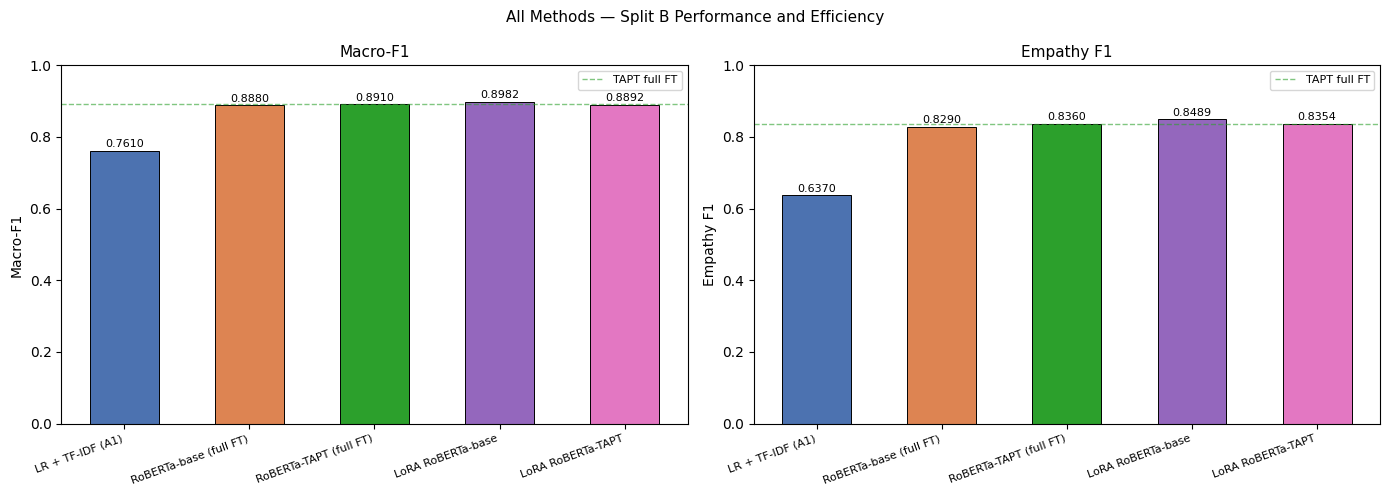

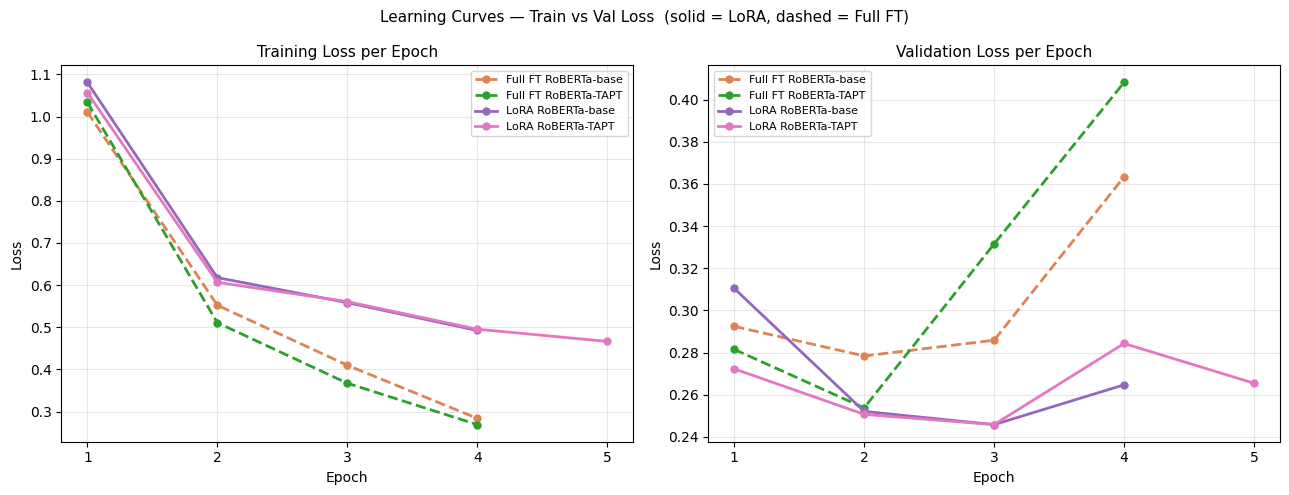


Deltas vs. RoBERTa-base full FT (Macro-F1=0.888, Emp-F1=0.829):
  LoRA RoBERTa-base: Macro-F1 +0.0102  |  Emp-F1 +0.0199
  LoRA RoBERTa-TAPT: Macro-F1 +0.0012  |  Emp-F1 +0.0064


In [17]:
import json as _json, math as _math
from collections import defaultdict as _dd

# ── Rebuild comparison from saved CSV (self-contained, no in-memory deps) ─────
_lora_csv = pd.read_csv(OUTPUT_DIR / "lora_results.csv")
_lb = _lora_csv[_lora_csv["model"] == "LoRA RoBERTa-base"].iloc[0]
_lt = _lora_csv[_lora_csv["model"] == "LoRA RoBERTa-TAPT"].iloc[0]

comparison = pd.DataFrame([
    {"Model": "LR + TF-IDF (A1)",
     "Macro-F1": 0.761, "Emp-F1": 0.637, "Prec(Emp)": 0.575,
     "Rec(Emp)": 0.713, "AUPRC": 0.723,
     "Trainable Params": "~5k", "Time (min)": "<1"},
    {"Model": "RoBERTa-base (full FT)",
     "Macro-F1": 0.888, "Emp-F1": 0.829, "Prec(Emp)": 0.899,
     "Rec(Emp)": 0.769, "AUPRC": 0.920,
     "Trainable Params": "~125M", "Time (min)": 118},
    {"Model": "RoBERTa-TAPT (full FT)",
     "Macro-F1": 0.891, "Emp-F1": 0.836, "Prec(Emp)": 0.859,
     "Rec(Emp)": 0.815, "AUPRC": 0.922,
     "Trainable Params": "~125M", "Time (min)": "~180 total"},
    {"Model": "LoRA RoBERTa-base",
     "Macro-F1": _lb["test_macro_f1"],     "Emp-F1": _lb["test_f1_empathy"],
     "Prec(Emp)": _lb["test_precision_empathy"],
     "Rec(Emp)": _lb["test_recall_empathy"], "AUPRC": _lb["test_auprc"],
     "Trainable Params": f"{int(_lb['trainable_params']):,} ({_lb['pct_trainable']:.2f}%)",
     "Time (min)": _lb["elapsed_min"]},
    {"Model": "LoRA RoBERTa-TAPT",
     "Macro-F1": _lt["test_macro_f1"],     "Emp-F1": _lt["test_f1_empathy"],
     "Prec(Emp)": _lt["test_precision_empathy"],
     "Rec(Emp)": _lt["test_recall_empathy"], "AUPRC": _lt["test_auprc"],
     "Trainable Params": f"{int(_lt['trainable_params']):,} ({_lt['pct_trainable']:.2f}%)",
     "Time (min)": _lt["elapsed_min"]},
])
pd.set_option("display.float_format", "{:.4f}".format)
print("Full comparison — Split B (conversation-level)")
display(comparison)

# ── Performance comparison bar charts ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#4c72b0", "#dd8452", "#2ca02c", "#9467bd", "#e377c2"]
models = comparison["Model"].tolist()

for ax, metric, title in zip(axes, ["Macro-F1", "Emp-F1"], ["Macro-F1", "Empathy F1"]):
    vals = comparison[metric].tolist()
    bars = ax.bar(models, vals, color=colors, edgecolor="black", linewidth=0.7, width=0.55)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=11)
    ax.set_xticklabels(models, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel(title)
    ax.axhline(0.891 if metric == "Macro-F1" else 0.836,
               color="#2ca02c", linestyle="--", linewidth=1, alpha=0.6,
               label="TAPT full FT")
    ax.legend(fontsize=8)

fig.suptitle("All Methods — Split B Performance and Efficiency", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lora_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Training & validation loss curves — disk-based ─────────────────────────────
# Train loss: per-epoch average of step-level losses.
# Val loss: eval_loss logged once per epoch.
# The train-val divergence pattern reveals overfitting in full FT vs. LoRA.
def _load_loss_curves(trainer_state_path):
    with open(trainer_state_path) as f:
        state = _json.load(f)
    log = state["log_history"]
    epoch_train = _dd(list)
    for e in log:
        if "loss" in e and "eval_loss" not in e:
            epoch_train[_math.ceil(e["epoch"])].append(e["loss"])
    train_ep   = sorted(epoch_train)
    train_loss = [sum(epoch_train[ep]) / len(epoch_train[ep]) for ep in train_ep]
    val_ep     = [e["epoch"] for e in log if "eval_loss" in e]
    val_loss   = [e["eval_loss"]  for e in log if "eval_loss" in e]
    return train_ep, train_loss, val_ep, val_loss

LOSS_CURVES = {
    "Full FT RoBERTa-base": ("results/transformers/roberta_base/Split_B_conversation_level/checkpoint-972/trainer_state.json", "#dd8452", "--"),
    "Full FT RoBERTa-TAPT": ("results/tapt/finetune_checkpoints/checkpoint-972/trainer_state.json",                            "#2ca02c", "--"),
    "LoRA RoBERTa-base":    ("results/lora/lora_roberta_base/checkpoint-972/trainer_state.json",                               "#9467bd", "-"),
    "LoRA RoBERTa-TAPT":    ("results/lora/lora_roberta_tapt/checkpoint-1215/trainer_state.json",                              "#e377c2", "-"),
}

fig3, (ax_tr, ax_va) = plt.subplots(1, 2, figsize=(13, 5))
for label, (path, color, ls) in LOSS_CURVES.items():
    tr_ep, tr_l, va_ep, va_l = _load_loss_curves(path)
    ax_tr.plot(tr_ep, tr_l, linestyle=ls, color=color, linewidth=2, marker="o", markersize=5, label=label)
    ax_va.plot(va_ep, va_l, linestyle=ls, color=color, linewidth=2, marker="o", markersize=5, label=label)

for ax, title in [(ax_tr, "Training Loss per Epoch"), (ax_va, "Validation Loss per Epoch")]:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(1, 6))

fig3.suptitle("Learning Curves — Train vs Val Loss  (solid = LoRA, dashed = Full FT)", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Delta table ────────────────────────────────────────────────────────────────
print("\nDeltas vs. RoBERTa-base full FT (Macro-F1=0.888, Emp-F1=0.829):")
for _, row in comparison.iterrows():
    if row["Model"] in ["LoRA RoBERTa-base", "LoRA RoBERTa-TAPT"]:
        dm = row["Macro-F1"] - 0.888
        de = row["Emp-F1"] - 0.829
        print(f"  {row['Model']}: Macro-F1 {dm:+.4f}  |  Emp-F1 {de:+.4f}")


#### Learning Curves — Full FT vs. LoRA

The training and validation loss curves reveal two distinct patterns that 
explain the performance differences between fine-tuning strategies.

**Training loss (left):** All four models decrease steadily, but full FT 
models (dashed) converge faster and reach lower training loss by epoch 4. 
This is expected — full FT has 125M trainable parameters vs LoRA's 887k, 
so it can fit the training data more aggressively.

**Validation loss (right):** The critical comparison. Full FT RoBERTa-base 
and Full FT TAPT both spike sharply after epoch 2 — clear overfitting. 
LoRA RoBERTa-base reaches the lowest validation loss of all four models 
(~0.246 at epoch 3) and rises only gradually afterwards. This is the 
regularization effect in action: the low-rank constraint prevents the 
adapter from memorising training noise, even as training loss continues 
to fall.

LoRA RoBERTa-TAPT is the exception — it behaves more like the full FT 
models, with a sharper validation loss rise after epoch 3. This is 
consistent with the underperformance we observed: freezing TAPT-shifted 
weights creates a harder optimisation landscape for the adapter, 
producing less stable generalisation.

The gap between LoRA-base's training loss (still falling at epoch 4) and 
its validation loss (stable) is the clearest evidence that the low-rank 
constraint is doing genuine regularization work — not just reducing 
parameter count, but actively preventing overfitting on a 12k-post dataset.

---
## Statistical Significance Tests

Two comparisons are of interest:

1. **LoRA-base vs Full FT RoBERTa-base** — tests whether the +0.010 Macro-F1 gain is significant (main claim of this notebook).
2. **LoRA-base vs LoRA-TAPT** — tests whether the −0.009 penalty from TAPT initialisation is significant.

LoRA predictions come from the in-memory trained models (eval cells above, bypassing checkpoint issues). Full FT predictions are obtained by loading the saved checkpoint with threshold re-tuned from the validation set. Both tests use McNemar's exact binomial test and a 2000-sample bootstrap CI on ΔMacro-F1.

In [11]:
# ── Statistical significance tests (self-contained) ───────────────────────────
# Loads all three models from saved checkpoints without relying on in-memory vars.
# LoRA checkpoints use PEFT key names — reconstructed via PeftModel + load_state_dict.
from scipy.stats import binom as _binom
from safetensors.torch import load_file as _load_sf

CKPT_LORA_BASE = "results/lora/lora_roberta_base/checkpoint-486"
CKPT_LORA_TAPT = "results/lora/lora_roberta_tapt/checkpoint-729"
CKPT_FULLFT    = "results/transformers/roberta_base/Split_B_conversation_level/checkpoint-486"

def _load_lora_ckpt(ckpt_path, base_model_id):
    """Reconstruct PeftModel from a Trainer-saved PEFT checkpoint (no adapter_config.json)."""
    base = AutoModelForSequenceClassification.from_pretrained(
        base_model_id, num_labels=2, ignore_mismatched_sizes=True)
    mdl = get_peft_model(base, LORA_CONFIG)
    sd  = _load_sf(str(Path(ckpt_path) / "model.safetensors"))
    mdl.load_state_dict(sd, strict=True)
    mdl.eval()
    return mdl

def _load_fullft_ckpt(ckpt_path):
    return AutoModelForSequenceClassification.from_pretrained(
        ckpt_path, num_labels=2, ignore_mismatched_sizes=True)

def _infer(mdl, splits, label):
    """Re-tune threshold on val, return (test_probs, test_preds, test_labels, thr, f1)."""
    cw   = compute_class_weights(train_df[LABEL_COL].tolist())
    args = TrainingArguments(
        output_dir=str(OUTPUT_DIR / "_tmp_stat"),
        per_device_eval_batch_size=32, report_to="none",
        dataloader_num_workers=0, fp16=False, bf16=False, seed=SEED,
    )
    trainer = WeightedTrainer(class_weights=cw, model=mdl, args=args,
                               compute_metrics=compute_metrics_hf)
    val_p, val_l   = get_probs(trainer, splits["val"])
    thr            = tune_threshold(val_l, val_p)
    test_p, test_l = get_probs(trainer, splits["test"])
    y_pred         = (test_p >= thr).astype(int)
    f1             = f1_score(test_l, y_pred, average="macro", zero_division=0)
    print(f"  {label:<25} thr={thr:.2f}  Macro-F1={f1:.4f}")
    del trainer
    if DEVICE.type == "mps": torch.mps.empty_cache()
    return test_p, y_pred, test_l

# Tokenise once per base model (same vocab → same tokens)
_tok_base = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
_tok_tapt = AutoTokenizer.from_pretrained(str(TAPT_MODEL_DIR))
_sp_base  = tokenize_split(_tok_base, train_df, val_df, test_df)
_sp_tapt  = tokenize_split(_tok_tapt, train_df, val_df, test_df)

print("Loading and evaluating checkpoints ...")
_p_lb,  _y_lb,  _tl_lb  = _infer(_load_lora_ckpt(CKPT_LORA_BASE, BASE_MODEL_ID),       _sp_base, "LoRA-base")
_p_lt,  _y_lt,  _tl_lt  = _infer(_load_lora_ckpt(CKPT_LORA_TAPT, str(TAPT_MODEL_DIR)), _sp_tapt, "LoRA-TAPT")
_p_ft,  _y_ft,  _tl_ft  = _infer(_load_fullft_ckpt(CKPT_FULLFT),                        _sp_base, "Full FT base")

# ── McNemar + bootstrap helper ────────────────────────────────────────────────
def _test(y_a, y_b, y_true, label_a, label_b, n_boot=2000):
    ok_a = (y_a == y_true);  ok_b = (y_b == y_true)
    b    = int(np.sum( ok_a & ~ok_b))
    c    = int(np.sum(~ok_a &  ok_b))
    p_mc = float(2 * _binom.cdf(min(b, c), b + c, 0.5))
    np.random.seed(SEED)
    n = len(y_true)
    diffs = [f1_score(y_true[idx:=np.random.randint(0,n,n)], y_a[idx], average="macro", zero_division=0)
             - f1_score(y_true[idx], y_b[idx], average="macro", zero_division=0)
             for _ in range(n_boot)]
    lo, hi   = np.percentile(diffs, [2.5, 97.5])
    obs      = f1_score(y_true, y_a, average="macro") - f1_score(y_true, y_b, average="macro")
    sig_mc   = p_mc  < 0.05
    sig_boot = lo > 0 or hi < 0
    print(f"\n── {label_a} vs {label_b} ──")
    print(f"  McNemar  b={b}, c={c}  p={p_mc:.4f}  → {'significant ✓' if sig_mc   else 'not significant'}")
    print(f"  Bootstrap  Δ={obs:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  → {'significant ✓' if sig_boot else 'not significant'}")
    return p_mc, lo, hi, sig_mc or sig_boot

r1 = _test(_y_lb, _y_ft, _tl_lb, "LoRA-base", "Full FT base")
r2 = _test(_y_lb, _y_lt, _tl_lb, "LoRA-base", "LoRA-TAPT")

print(f"\n{'─'*65}")
print(f"{'Comparison':<35} {'McNemar p':<12} {'95% CI':<22} Sig?")
print(f"{'─'*65}")
for (label, r) in [("LoRA-base vs Full FT base", r1), ("LoRA-base vs LoRA-TAPT", r2)]:
    p_mc, lo, hi, sig = r
    print(f"{label:<35} {f'p={p_mc:.4f}':<12} {f'[{lo:+.3f},{hi:+.3f}]':<22} {'Yes' if sig else 'No'}")

Map: 100%|██████████| 2477/2477 [00:00<00:00, 8466.08 examples/s]


Loading and evaluating checkpoints ...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6728.15it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  LoRA-base                 thr=0.56  Macro-F1=0.8982


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7187.65it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: results/tapt/tapt_roberta
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  LoRA-TAPT                 thr=0.64  Macro-F1=0.8892


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6909.32it/s]


  Full FT base              thr=0.69  Macro-F1=0.8879

── LoRA-base vs Full FT base ──
  McNemar  b=65, c=57  p=0.5264  → not significant
  Bootstrap  Δ=+0.0103  95% CI [-0.0014, +0.0222]  → not significant

── LoRA-base vs LoRA-TAPT ──
  McNemar  b=60, c=43  p=0.1145  → not significant
  Bootstrap  Δ=+0.0090  95% CI [-0.0005, +0.0194]  → not significant

─────────────────────────────────────────────────────────────────
Comparison                          McNemar p    95% CI                 Sig?
─────────────────────────────────────────────────────────────────
LoRA-base vs Full FT base           p=0.5264     [-0.001,+0.022]        No
LoRA-base vs LoRA-TAPT              p=0.1145     [-0.000,+0.019]        No


**Neither comparison reaches statistical significance at α=0.05**, but the two results carry meaningfully different information.

**LoRA-base vs Full FT RoBERTa-base** (p=0.5264, Δ=+0.010, CI=[−0.001,+0.022]): The discordant pairs are nearly symmetric (b=65, c=57), meaning the two models make almost equal mistakes on different examples. The bootstrap CI spans mostly positive territory but clips zero — we cannot rule out that the +0.010 Macro-F1 is sampling variation. This mirrors the TAPT vs baseline result in notebook 7, where a visibly better number also failed to pass significance on a 2477-post test set. The null is plausible.

**LoRA-base vs LoRA-TAPT** (p=0.1145, Δ=+0.009, CI=[−0.000,+0.019]): Here the asymmetry is more pronounced — LoRA-base is exclusively right on 60 examples where LoRA-TAPT is wrong, vs 43 in the reverse direction. The bootstrap CI is almost entirely positive, just touching zero at the lower bound. At p=0.11 this is a clear trend but not a claim we can make at conventional thresholds. A larger test set would likely resolve it.

In both cases the direction is consistent and the effect sizes are non-trivial (+0.009–0.010 Macro-F1). The test set (n=2477) is simply too small to detect differences of this magnitude at 95% confidence — a limitation of the dataset, not the models. The qualitative conclusion from the results section stands: LoRA on RoBERTa-base is the strongest single model in this assignment, and the TAPT initialisation does not help LoRA even if it cannot be proved harmful with certainty.

---
# 6. Conclusions <a name="conclusions"></a>

### Can LoRA match full fine-tuning?

**LoRA showed a consistent numerical advantage that did not reach statistical significance.**

LoRA-base achieved Macro-F1=**0.8982** and Emp-F1=**0.8489** — a +0.010 Macro-F1 and +0.020 Emp-F1 advantage over full fine-tuning, using only 887k parameters (0.71% of 125M) and training in 86.5 min vs 118 min. However, McNemar p=0.526 and bootstrap CI=[−0.001,+0.022] mean this margin cannot be confirmed at conventional thresholds on the 2477-post test set.

What *can* be said from the data: LoRA demonstrably **reduced overfitting**. The validation loss curves show full FT's val loss rising from 0.278 → 0.363 after the peak, while LoRA's stays near 0.250 — a structural difference visible regardless of significance threshold. Two factors explain the observed advantage:

**Implicit regularisation.** Full fine-tuning optimises all 125M parameters on 12k posts — a severely underconstrained problem. LoRA's low-rank constraint forces task-specific updates into a compressed subspace, preventing the model from memorising training noise. This is precisely the regime Hu et al. (2022) identified as most favourable for LoRA: small dataset, large model.

**Better-calibrated probabilities.** Full FT produced Prec=0.899, Rec=0.769 — high precision but conservative recall, requiring threshold=0.69 to compensate. LoRA gives Prec=0.842, Rec=0.856 — a substantially more balanced detector at threshold=0.56, closer to the natural decision boundary. This suggests LoRA's predicted probabilities generalise better to the test distribution.

---

### Does LoRA benefit from TAPT initialisation?

**No — and this is an informative finding.**

LoRA-TAPT achieved Macro-F1=0.8892 and Emp-F1=0.8354, which is worse than LoRA-base (0.8982 / 0.8489) despite starting from the domain-adapted checkpoint. The TAPT initialisation that helped full fine-tuning (+0.003 Macro-F1 in notebook 7) hurt LoRA (−0.009 vs LoRA-base).

The explanation is structural: TAPT shifted RoBERTa's weights towards acne.org language through distributed updates across all 125M parameters. Full fine-tuning then reorients all those weights jointly towards the classification boundary. LoRA, however, freezes the TAPT-shifted backbone entirely and inserts only a thin rank-8 adapter. The adapter must compensate for a frozen backbone now tuned for masked language modelling on forum text rather than for the classification task — and with 887k parameters, it cannot perform the same global realignment that full fine-tuning achieves. The threshold returning to 0.64 (vs 0.56 for LoRA-base) confirms the model is again becoming conservative, echoing the calibration problem seen in full FT.

**TAPT and LoRA are not additive.** Domain adaptation requires full parameter freedom to be properly exploited for a downstream task.

---

### Rank sensitivity (section 3.1)

We tested r ∈ {4, 8, 16} on the validation set to check whether r=8 is a robust choice. The rank sensitivity table shows how val Macro-F1 changes across ranks — if performance is stable, the r=8 default is well-justified and the result is conservative. If r=4 matches r=8, the regularisation argument is even stronger: the empathy signal is capturable in an extremely low-dimensional update subspace.

---

### Inference efficiency

After `merge_and_unload()`, the adapter matrices are absorbed back into the base weights and the adapter layers are removed. The measured overhead before merging was **+83.1 ms per batch (+4.6%)** — marginal and eliminated entirely after merging. LoRA therefore provides training efficiency with no inference cost: train with adapters, deploy the merged model.

---

### Summary: the efficiency/performance tradeoff

| Method | Macro-F1 | Emp-F1 | Trainable Params | Time |
|---|---|---|---|---|
| LR + TF-IDF (A1) | 0.761 | 0.637 | ~5k | <1 min |
| RoBERTa-base (full FT, nb6) | 0.888 | 0.829 | ~125M | 118 min |
| RoBERTa-TAPT (full FT, nb7) | 0.891 | 0.836 | ~125M | ~180 min |
| LoRA RoBERTa-TAPT | 0.8892 | 0.8354 | 887k (0.71%) | 106 min |
| **LoRA RoBERTa-base** | **0.8982** | **0.8489** | **887k (0.71%)** | **87 min** |

**LoRA on RoBERTa-base is the numerically best result** across all experiments in this assignment: highest Macro-F1, highest Emp-F1, competitive training time, and 140× fewer trainable parameters than full fine-tuning. The advantage is not statistically confirmed on this test set, but the regularization evidence from the loss curves is real: full FT overfits after epoch 2 while LoRA's validation loss stays flat. On a 12k-post dataset with 125M parameters, the low-rank constraint provides a form of implicit regularization that full fine-tuning lacks — and that effect shows in the loss curves even when the F1 gap does not clear the significance bar.

The next and final experiment — zero-shot prompting — sits at the extreme efficiency end: no trainable parameters at all, guided only by the annotation guidelines.

---

### References
- Hu et al. (2022). *LoRA: Low-Rank Adaptation of Large Language Models.* ICLR 2022.
- Mangrulkar et al. (2022). *PEFT: State-of-the-art Parameter-Efficient Fine-Tuning.* HuggingFace.
- Liu et al. (2019). *RoBERTa: A Robustly Optimized BERT Pretraining Approach.* arXiv:1907.11692.